# Cops and robber in a DAG

You are given a directed acyclic graph (DAG) $G$ with $n$ vertices and $m$ edges, a number $B$ and real vectors $x^{\text{max}}\in \mathbb{R}^m$, $a\in \mathbb{R}^m$. A robber wants to get from vertex 1 to vertex $n$. The cops want to prevent it, by assigning $x_e \in [0, x^{\text{max}}_e]$ of resources to every edge $e\in E(G)$. Then, the probability that the robber safely goes through any edge $e$ is $\exp(-a_ex_e)$, independently for every edge. Moreover, $B$ is the upper bound on the total amount of cops' resources, i.e., $\sum_e x_e \le B$. Find the assignment of resources that minimizes $p^\star$, where $p^\star$ is the maximum probability that the robber travels safely from 1 to $n$, over all paths in the DAG. Compare $p^\star$ with the probability obtained for the uniform distribution of police's resources.

(This exercise is inspired by the collection *Additional Exercises for Convex Optimization* by Boyd and Vandenberghe, used under permission.)

In [1]:
import numpy as np

In [ ]:
np.random.seed(123)
n = 10
m = 20
B = m / 2
edges = np.array([[1,1,1,2,2,2,3,3,4,4,5,5,6,6,7,7,8,7,8,9],[2,3,4,6,3,4,5,6,6,7,8,7,7,8,8,9,9,10,10,10]]).T-1
edges

array([[0, 1],
       [0, 2],
       [0, 3],
       [1, 5],
       [1, 2],
       [1, 3],
       [2, 4],
       [2, 5],
       [3, 5],
       [3, 6],
       [4, 7],
       [4, 6],
       [5, 6],
       [5, 7],
       [6, 7],
       [6, 8],
       [7, 8],
       [6, 9],
       [7, 9],
       [8, 9]])

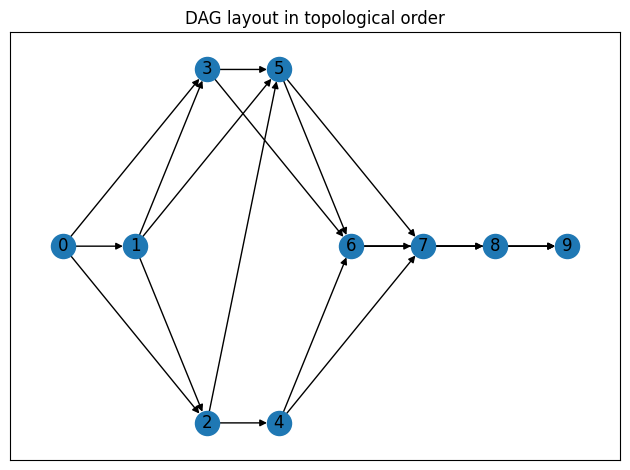

In [3]:
import networkx as nx
from matplotlib import pyplot as plt
G = nx.DiGraph()
G.add_edges_from(edges)

for layer, nodes in enumerate(nx.topological_generations(G)):
    # `multipartite_layout` expects the layer as a node attribute, so add the
    # numeric layer value as a node attribute
    for node in nodes:
        G.nodes[node]["layer"] = layer

# Compute the multipartite_layout using the "layer" node attribute
pos = nx.multipartite_layout(G, subset_key="layer")

fig, ax = plt.subplots()
nx.draw_networkx(G, pos=pos, ax=ax)
ax.set_title("DAG layout in topological order")
fig.tight_layout()
plt.show()

In [4]:
a = 2 * np.random.rand(m)
x_max = 1 + np.random.rand(m)

In [7]:
from gurobipy import Model, GRB

In [8]:
robber_m = Model("robber_model")

Restricted license - for non-production use only - expires 2027-11-29


In [ ]:
x = robber_m.addMVar(shape=m, name="x") # to find the uniform distribution, add bounds ub=B/m, lb=B/m
z = robber_m.addMVar(shape=n, name="z", lb=-GRB.INFINITY)

i = 0
for edge in edges:
    robber_m.addConstr(z[edge[1]] >= z[edge[0]] - a[i]*x[i], name=f"edge_{edge[0]}_{edge[1]}")
    i += 1

robber_m.addConstr(np.ones((1, m)) @ x <= B, name="budget")
robber_m.addConstr(z[0] == 0, name="start")

[0 1]
1.3929383711957233
[0 2]
0.5722786699007589
[0 3]
0.4537029071284062
[1 5]
1.1026295381657825
[1 2]
1.4389379395711261
[1 3]
0.8462129202489219
[2 4]
1.961528396769231
[2 5]
1.3696594771697266
[3 5]
0.9618638029687219
[3 6]
0.784235036388301
[4 7]
0.6863560323017388
[4 6]
1.4580994147680832
[5 6]
0.8771444893592488
[5 7]
0.1193557932191367
[6 7]
0.7960885106608628
[6 8]
1.4759908114640714
[7 8]
0.36498346090699996
[6 9]
0.35090351229498506
[7 9]
1.0631027476836767
[8 9]
1.0636551741937321


<MConstr () *awaiting model update*>

In [12]:
robber_m.setObjective(z[n-1], GRB.MINIMIZE)

In [13]:
robber_m.optimize()

Gurobi Optimizer version 13.0.1 build v13.0.1rc0 (mac64[arm] - Darwin 25.3.0 25D2128)

CPU model: Apple M4 Pro
Thread count: 14 physical cores, 14 logical processors, using up to 14 threads

Optimize a model with 22 rows, 30 columns and 81 nonzeros (Min)
Model fingerprint: 0xd8eafdbc
Model has 1 linear objective coefficients
Coefficient statistics:
  Matrix range     [1e-01, 2e+00]
  Objective range  [1e+00, 1e+00]
  Bounds range     [5e-01, 5e-01]
  RHS range        [1e+01, 1e+01]

Presolve removed 22 rows and 30 columns
Presolve time: 0.00s
Presolve: All rows and columns removed
Iteration    Objective       Primal Inf.    Dual Inf.      Time
       0   -7.9442073e-01   0.000000e+00   0.000000e+00      0s

Solved in 0 iterations and 0.00 seconds (0.00 work units)
Optimal objective -7.944207279e-01


In [14]:
np.exp(robber_m.ObjVal)

np.float64(0.45184289911029046)

In [15]:
x

<MVar (20,)>
array([<gurobi.Var x[0] (value 0.5)>, <gurobi.Var x[1] (value 0.5)>,
       <gurobi.Var x[2] (value 0.5)>, <gurobi.Var x[3] (value 0.5)>,
       <gurobi.Var x[4] (value 0.5)>, <gurobi.Var x[5] (value 0.5)>,
       <gurobi.Var x[6] (value 0.5)>, <gurobi.Var x[7] (value 0.5)>,
       <gurobi.Var x[8] (value 0.5)>, <gurobi.Var x[9] (value 0.5)>,
       <gurobi.Var x[10] (value 0.5)>, <gurobi.Var x[11] (value 0.5)>,
       <gurobi.Var x[12] (value 0.5)>, <gurobi.Var x[13] (value 0.5)>,
       <gurobi.Var x[14] (value 0.5)>, <gurobi.Var x[15] (value 0.5)>,
       <gurobi.Var x[16] (value 0.5)>, <gurobi.Var x[17] (value 0.5)>,
       <gurobi.Var x[18] (value 0.5)>, <gurobi.Var x[19] (value 0.5)>])